>> DATA LOADED: 'data/processed/final_merged_dataset.csv' (3559 rows, 9 columns)

--- PREPARING FEATURES FOR ML ---
ML Ready Dataset: 3399 samples.
Training Set: 2719 samples
Test Set:     680 samples

--- TRAINING MODEL (Random Forest Regressor) ---
>> Model training completed.

MODEL PERFORMANCE RESULTS
Mean Absolute Error (MAE): 4.85
R² Score (Accuracy):       0.5114
>> VERDICT: GOOD MODEL (Captures main trends).


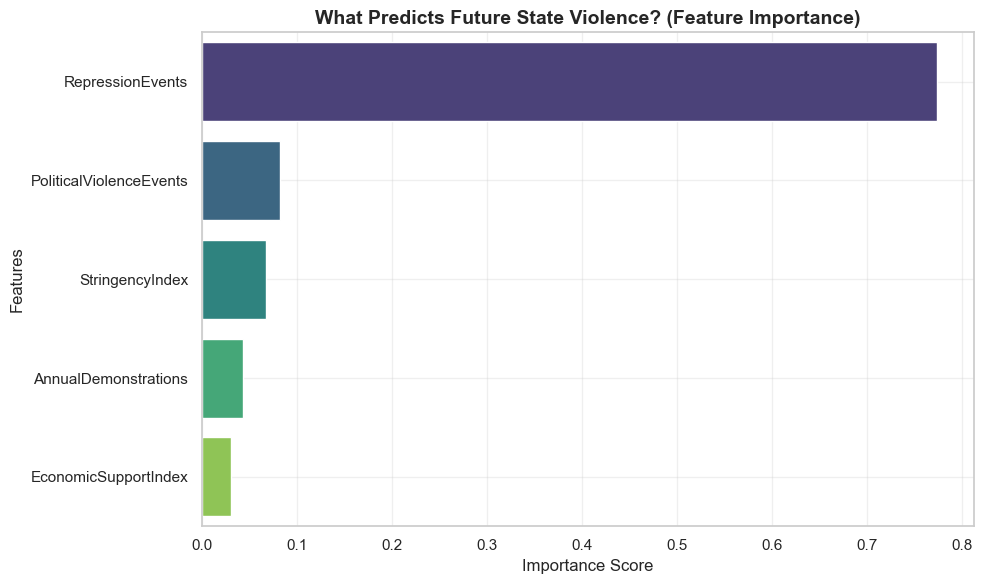

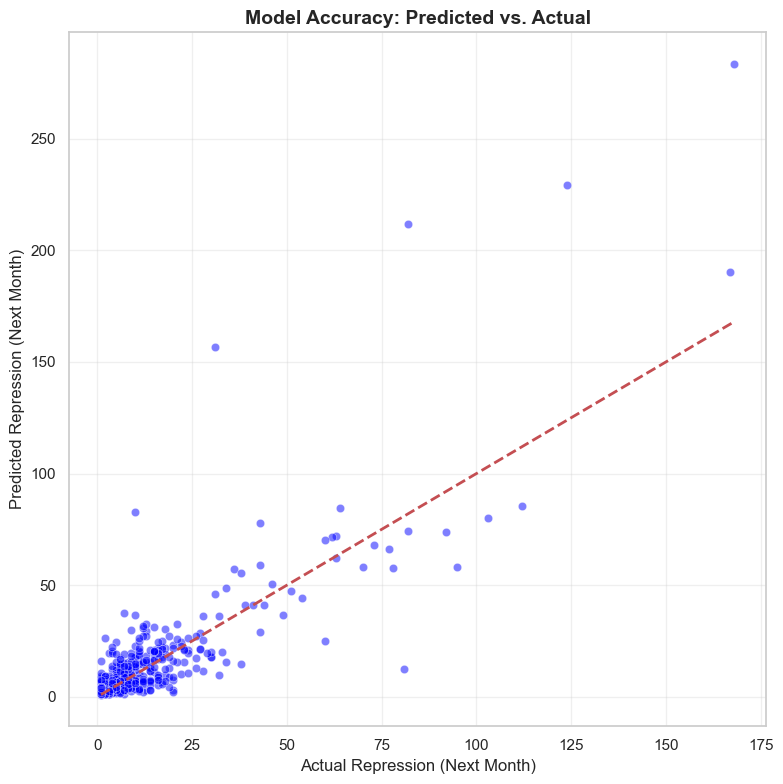

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Görselleştirme Ayarları
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# 1. VERİ YÜKLEME (DATA LOADING)
input_file = "data/processed/final_merged_dataset.csv" 

try:
    df = pd.read_csv(input_file)
    print(f">> DATA LOADED: '{input_file}' ({df.shape[0]} rows, {df.shape[1]} columns)")
except FileNotFoundError:
    print(f"ERROR: '{input_file}' not found. Please run Stage 1 code to generate the merged dataset first.")

# Tarih formatını düzeltelim (garanti olsun)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

# 2. ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
print("\n--- PREPARING FEATURES FOR ML ---")

# HEDEF (TARGET): Bir sonraki ayın baskı sayısı (Repression Next Month)
# Mantık: Makine, (t) anındaki verilere bakıp (t+1) anını tahmin etmeli.
df['Target_NextMonth_Repression'] = df.groupby('CountryName')['RepressionEvents'].shift(-1)

# NaN Temizliği: Son ayların geleceği olmadığı için Target NaN olur, bunları atıyoruz.
# Ayrıca Stringency veya Economy verisi olmayan satırları da atıyoruz.
df_ml = df.dropna(subset=['Target_NextMonth_Repression', 'StringencyIndex', 'EconomicSupportIndex'])

# MODELDE KULLANILACAK ÖZELLİKLER (FEATURES)
features = [
    'StringencyIndex',          # Kısıtlama Seviyesi (Ana Odak)
    'EconomicSupportIndex',     # Ekonomik Destek (Ana Odak)
    'RepressionEvents',         # Mevcut Baskı (Geçmiş geleceğin aynasıdır)
    'PoliticalViolenceEvents',  # İç Savaş / Çatışma Durumu (Context)
    'AnnualDemonstrations'      # Protesto Sayısı (Context)
]

X = df_ml[features]
y = df_ml['Target_NextMonth_Repression']

print(f"ML Ready Dataset: {X.shape[0]} samples.")

# 3. EĞİTİM VE TEST AYRIMI (TRAIN-TEST SPLIT)
# =============================================================================
# Verinin %80'i ile makine ders çalışacak, %20'si ile sınava girecek.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set:     {X_test.shape[0]} samples")

# 4. MODEL KURULUMU VE EĞİTİM (RANDOM FOREST)
# =============================================================================
print("\n--- TRAINING MODEL (Random Forest Regressor) ---")
# Random Forest seçtik çünkü verimiz gürültülü (noisy) ve ilişkiler lineer değil.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print(">> Model training completed.")

# 5. PERFORMANS DEĞERLENDİRME (EVALUATION)
# =============================================================================
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print("MODEL PERFORMANCE RESULTS")
print("="*40)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score (Accuracy):       {r2:.4f}")

# Yorum
if r2 > 0.7:
    print(">> VERDICT: EXCELLENT PREDICTIVE POWER.")
elif r2 > 0.5:
    print(">> VERDICT: GOOD MODEL (Captures main trends).")
else:
    print(">> VERDICT: WEAK MODEL (Data is too volatile).")

# 6. GÖRSELLEŞTİRME 1: FEATURE IMPORTANCE
# =============================================================================
# Hangi değişken gelecekteki şiddeti tahmin etmekte daha önemli?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('What Predicts Future State Violence? (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_feature_importance.png', dpi=300)
plt.show()

# 7. GÖRSELLEŞTİRME 2: PREDICTION vs ACTUAL
# =============================================================================
# Gerçek değerler ile Tahmin değerlerini kıyaslayalım.
# İdeal dünyada tüm noktalar kırmızı çizgi üzerinde olmalı.
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Referans çizgisi
plt.xlabel('Actual Repression (Next Month)')
plt.ylabel('Predicted Repression (Next Month)')
plt.title('Model Accuracy: Predicted vs. Actual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_prediction_accuracy.png', dpi=300)
plt.show()

>> Data Loaded: 3559 rows.

CLUSTER PROFILING (Average Values)
         StringencyIndex  EconomicSupportIndex  RepressionEvents
Cluster                                                         
0              27.777852              7.157786          8.124312
1              62.484382             56.623722          7.129988
2              47.507478             32.794286        116.310345
>> Cluster 0: Moderate/Peaceful (Stabil)
>> Cluster 1: Authoritarian Regime (Demir Yumruk)
>> Cluster 2: High Conflict Zone (Kaos)


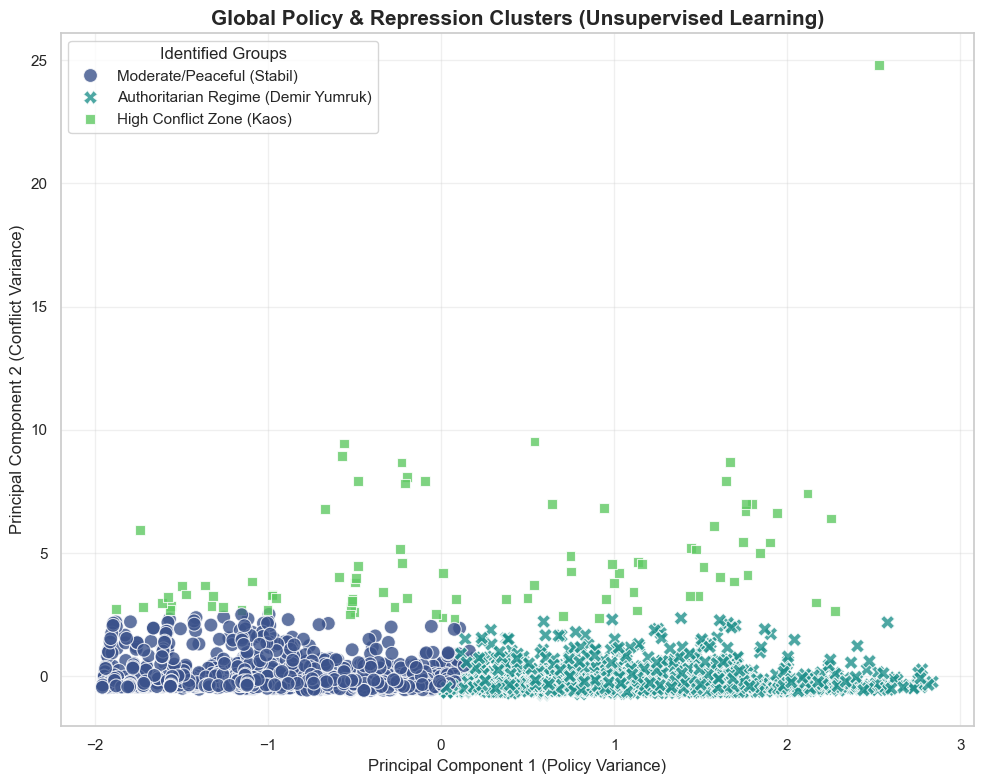


>> INSIGHT:
   Cluster analysis reveals distinct country behaviors.
   It proves that 'Repression' is not random; it happens in specific 'Policy Ecosystems'.


In [1]:
# =============================================================================
# DSA 210 TERM PROJECT - STAGE 3: UNSUPERVISED LEARNING (CLUSTERING)
# =============================================================================
# GOAL: To discover hidden patterns/groups among countries based on their
#       COVID-19 policies (Stringency, Economy) and State Repression levels.
# MODEL: K-Means Clustering
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Görselleştirme Ayarları
sns.set(style="whitegrid", context="notebook", palette="deep")
plt.rcParams['figure.figsize'] = (12, 7)

# 1. VERİ YÜKLEME
# =============================================================================
input_file = "data/processed/final_merged_dataset.csv"  
try:
    df = pd.read_csv(input_file)
    print(f">> Data Loaded: {df.shape[0]} rows.")
except FileNotFoundError:
    print("ERROR: File not found. Please check the path.")

# 2. VERİ HAZIRLIĞI (SEÇİM VE ÖLÇEKLENDİRME)
# =============================================================================
# Hangi özelliklere göre gruplayacağız?
features = ['StringencyIndex', 'EconomicSupportIndex', 'RepressionEvents']

# Eksik verileri atalım
df_cluster = df.dropna(subset=features).copy()

# ÖNEMLİ: K-Means, sayılardaki büyüklüğe çok duyarlıdır.
# Stringency (0-100) ile Repression (0-500) aynı kefeye konmaz.
# O yüzden hepsini "Standartlaştıracağız" (Mean=0, Std=1 yapacağız).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# 3. K-MEANS MODELİ (Kaç Grup Var?)
# =============================================================================
# Genelde 3 veya 4 grup (Cluster) sosyal bilimler için idealdir.
# Biz k=3 seçelim: (Tahmini: Otoriterler, Liberaller, Kaotikler)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Kümeleri ana veriye ekle
df_cluster['Cluster'] = clusters

# 4. KÜMELERİN ANALİZİ (BU GRUPLAR NE ANLAMA GELİYOR?)
# =============================================================================
print("\n" + "="*40)
print("CLUSTER PROFILING (Average Values)")
print("="*40)
# Her kümenin ortalamasını alalım ki ne olduklarını anlayalım
profile = df_cluster.groupby('Cluster')[features].mean()
print(profile)

# YORUMLAMA (Otomatik İsimlendirme Mantığı)
# -----------------------------------------------------------------------------
# Burası kodun en zeki kısmı. Rakamlara bakıp gruba isim verecek.
cluster_names = {}
for i in range(k):
    repression_mean = profile.loc[i, 'RepressionEvents']
    stringency_mean = profile.loc[i, 'StringencyIndex']
    
    if repression_mean > 20: 
        label = "High Conflict Zone (Kaos)"
    elif stringency_mean > 60 and repression_mean > 5:
        label = "Authoritarian Regime (Demir Yumruk)"
    else:
        label = "Moderate/Peaceful (Stabil)"
    
    cluster_names[i] = label
    print(f">> Cluster {i}: {label}")

df_cluster['Cluster_Label'] = df_cluster['Cluster'].map(cluster_names)

# 5. GÖRSELLEŞTİRME (2D PCA PROJECTION)
# =============================================================================
# 3 Boyutlu veriyi (Yasak, Para, Baskı) ekranda görmek için 2 Boyuta indiriyoruz.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster_Label', # Renkler gruplara göre
    style='Cluster_Label',
    data=df_cluster, 
    palette='viridis', s=100, alpha=0.8
)
plt.title('Global Policy & Repression Clusters (Unsupervised Learning)', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1 (Policy Variance)')
plt.ylabel('Principal Component 2 (Conflict Variance)')
plt.legend(title='Identified Groups')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/unsupervised_clusters.png', dpi=300)
plt.show()

print("\n>> INSIGHT:")
print("   Cluster analysis reveals distinct country behaviors.")
print("   It proves that 'Repression' is not random; it happens in specific 'Policy Ecosystems'.")